In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anay9877","key":"3805fd42863048dc0ab6559a5efba827"}'}

In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [ ]:
!kaggle datasets download -d chethuhn/network-intrusion-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:01<00:00, 222MB/s]



In [ ]:
import pandas as pd
import glob

files = glob.glob("/content/*.csv")

dfs = []
for f in files:
  df = pd.read_csv(f, encoding="latin1", low_memory=False)
  df.columns = df.columns.str.strip()
  df['Label'] = df['Label'].str.strip().str.replace('ï¿½', '-', regex=False)
  dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(df_all.shape)
print(df_all['Label'].value_counts)

(2830743, 79)
<bound method IndexOpsMixin.value_counts of 0          BENIGN
1          BENIGN
2          BENIGN
3          BENIGN
4          BENIGN
            ...  
2830738    BENIGN
2830739    BENIGN
2830740    BENIGN
2830741    BENIGN
2830742    BENIGN
Name: Label, Length: 2830743, dtype: object>


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_all.to_parquet("/home/cicids2017_clean.parquet", index=False)
print("Saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved!


In [ ]:
df_all = pd.read_parquet("/content/drive/MyDrive/cicids2017_clean.parquet")

In [ ]:
df_all.drop(columns=['Fwd Header Length.1'], inplace=True)
df_all.shape

(2830743, 78)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import numpy as np

df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
null_counts = df_all.isnull().sum()
print(null_counts[null_counts > 0])

Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


In [ ]:
df_all.dropna(inplace=True)
df_all.reset_index(drop=True, inplace=True)
print(df_all.shape)

(2827876, 78)


In [ ]:
for col in df_all.columns:
    if df_all[col].dtype == 'float64':
        df_all[col] = df_all[col].astype('float32')
    elif df_all[col].dtype == 'int64':
        df_all[col] = df_all[col].astype('int32')

print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Memory: 1027.3 MB


In [ ]:
df_all.to_parquet("/content/drive/MyDrive/cicids2017_clean.parquet", index=False)
print("Saved!")

Saved!


In [ ]:
def bucket_port(port):
  if port <= 1023:
    return 0
  elif port <= 49151:
    return 1
  else:
    return 2

df_all['Port_Category'] = df_all['Destination Port'].apply(bucket_port)
df_all.drop(columns=['Destination Port'], inplace=True)
df_all.shape

(2827876, 78)

In [ ]:
before = len(df_all)
df_all.drop_duplicates(inplace=True)
df_all.reset_index(drop=True, inplace=True)
after = len(df_all)
print(f"Removed {before - after} duplicate rows")
print(df_all.shape)

Removed 610120 duplicate rows
(2217756, 78)


In [ ]:
df_all['payload_ratio_fwd'] = df_all['act_data_pkt_fwd'] / (df_all['Total Fwd Packets'] + 1e-6)
df_all['fwd_bwd_packet_ratio'] = df_all['Total Fwd Packets'] / (df_all['Total Backward Packets'] + 1e-6)
print(df_all.shape)

(2217756, 80)


In [ ]:
df_all['payload_ratio_fwd'] = df_all['act_data_pkt_fwd'] / (df_all['Total Fwd Packets'] + 1e-6)
df_all['fwd_bwd_packet_ratio'] = df_all['Total Fwd Packets'] / (df_all['Total Backward Packets'] + 1e-6)
print(df_all.shape)

(2217756, 80)


In [ ]:
df_all.to_parquet("/content/drive/MyDrive/cicids2017_clean.parquet", index=False)
print("Saved!")

Saved!


In [ ]:
import pandas as pd

df_all = pd.read_parquet("/content/drive/MyDrive/cicids2017_clean.parquet")
print(df_all.shape)
print(df_all['Label'].value_counts())

(2217756, 80)
Label
BENIGN                        1880669
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         2514
Bot                              1474
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
print(df_all['Label'].value_counts())
print("\nClass percentages:")
print((df_all['Label'].value_counts() / len(df_all) * 100).round(2))

Label
BENIGN                        1880669
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         2514
Bot                              1474
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class percentages:
Label
BENIGN                        84.80
DoS Hulk                       7.79
DDoS                           5.77
DoS GoldenEye                  0.46
FTP-Patator                    0.27
DoS slowloris                  0.24
DoS Slowhttptest               0.24
SSH-Patator                    0.15
PortScan                       0.11
Bot                            0.07
Web Attack -

In [ ]:
# Dropping Infiltration, Web Attack - SQL Injection, Heartbleed as they
# as they contribute very less to the output and merging them into Rare Attacks
# would be like 'These 3 are all different attacks why are you classifying
# them into a same group??'

df_all = df_all[~df_all['Label'].isin(['Infiltration', 'Web Attack - Sql Injection', 'Heartbleed'])]
print(df_all.shape)
print(df_all['Label'].value_counts())

(2217688, 80)
Label
BENIGN                      1880669
DoS Hulk                     172846
DDoS                         128014
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
PortScan                       2514
Bot                            1474
Web Attack - Brute Force       1470
Web Attack - XSS                652
Name: count, dtype: int64


In [ ]:
# Creating a small sample of 100_000 for training or EDA purposes later would
# come back to 2.2M sample size

from sklearn.model_selection import train_test_split
sample, _ = train_test_split(df_all, train_size=100_000, stratify=df_all['Label'], random_state=42)
print(sample['Label'].value_counts())

Label
BENIGN                      84803
DoS Hulk                     7794
DDoS                         5772
DoS GoldenEye                 464
FTP-Patator                   268
DoS slowloris                 243
DoS Slowhttptest              236
SSH-Patator                   145
PortScan                      113
Bot                            67
Web Attack - Brute Force       66
Web Attack - XSS               29
Name: count, dtype: int64


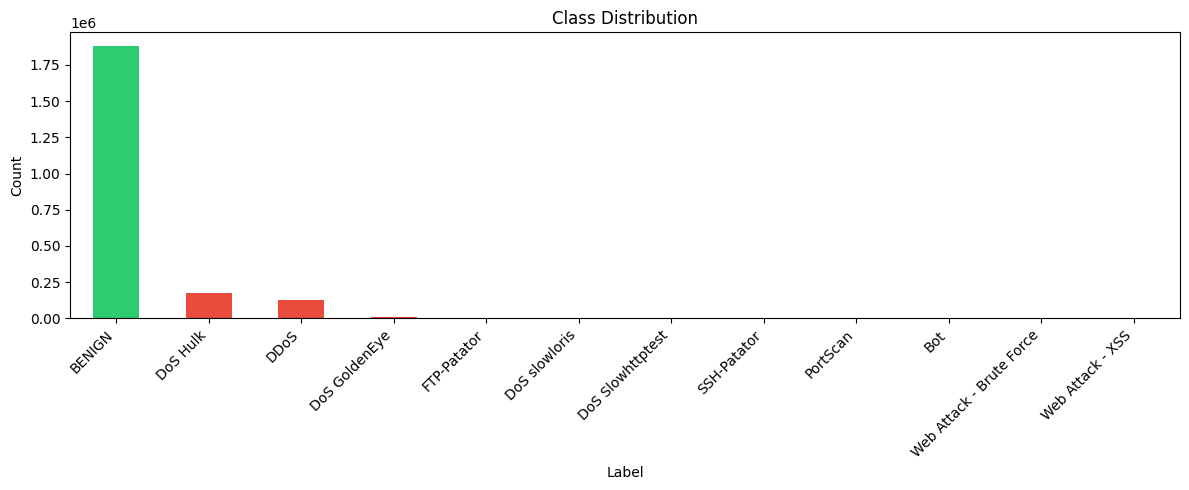

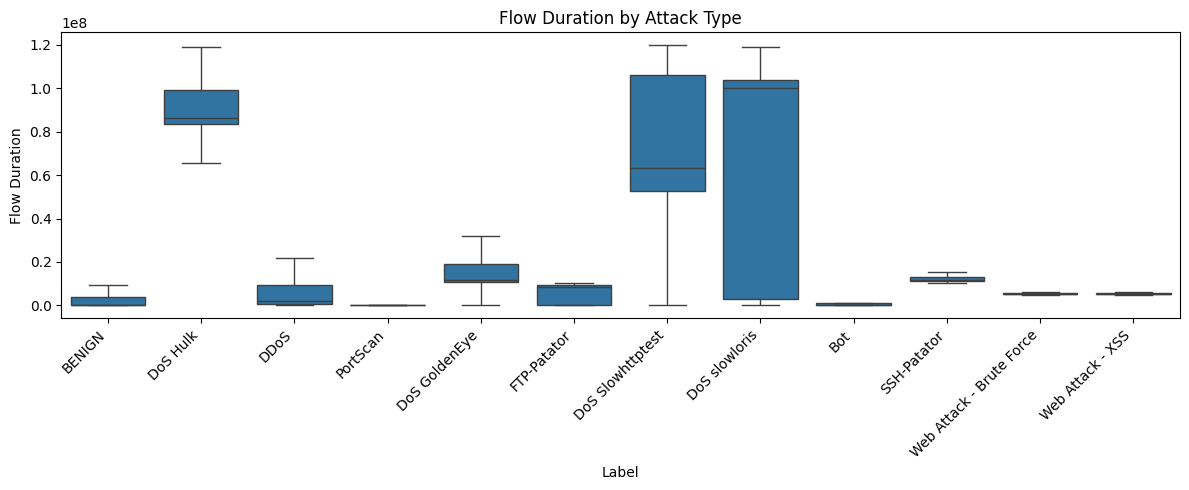

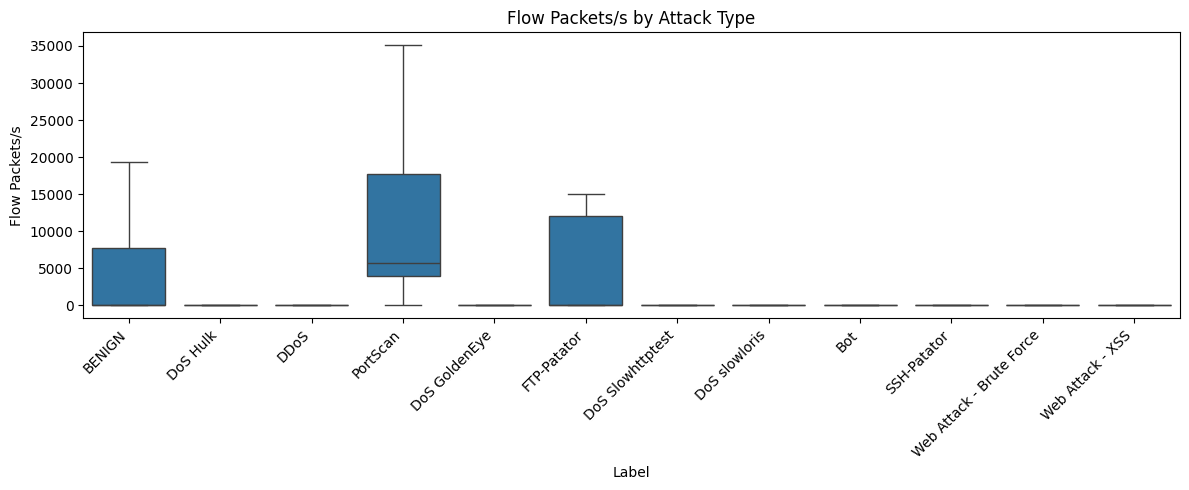

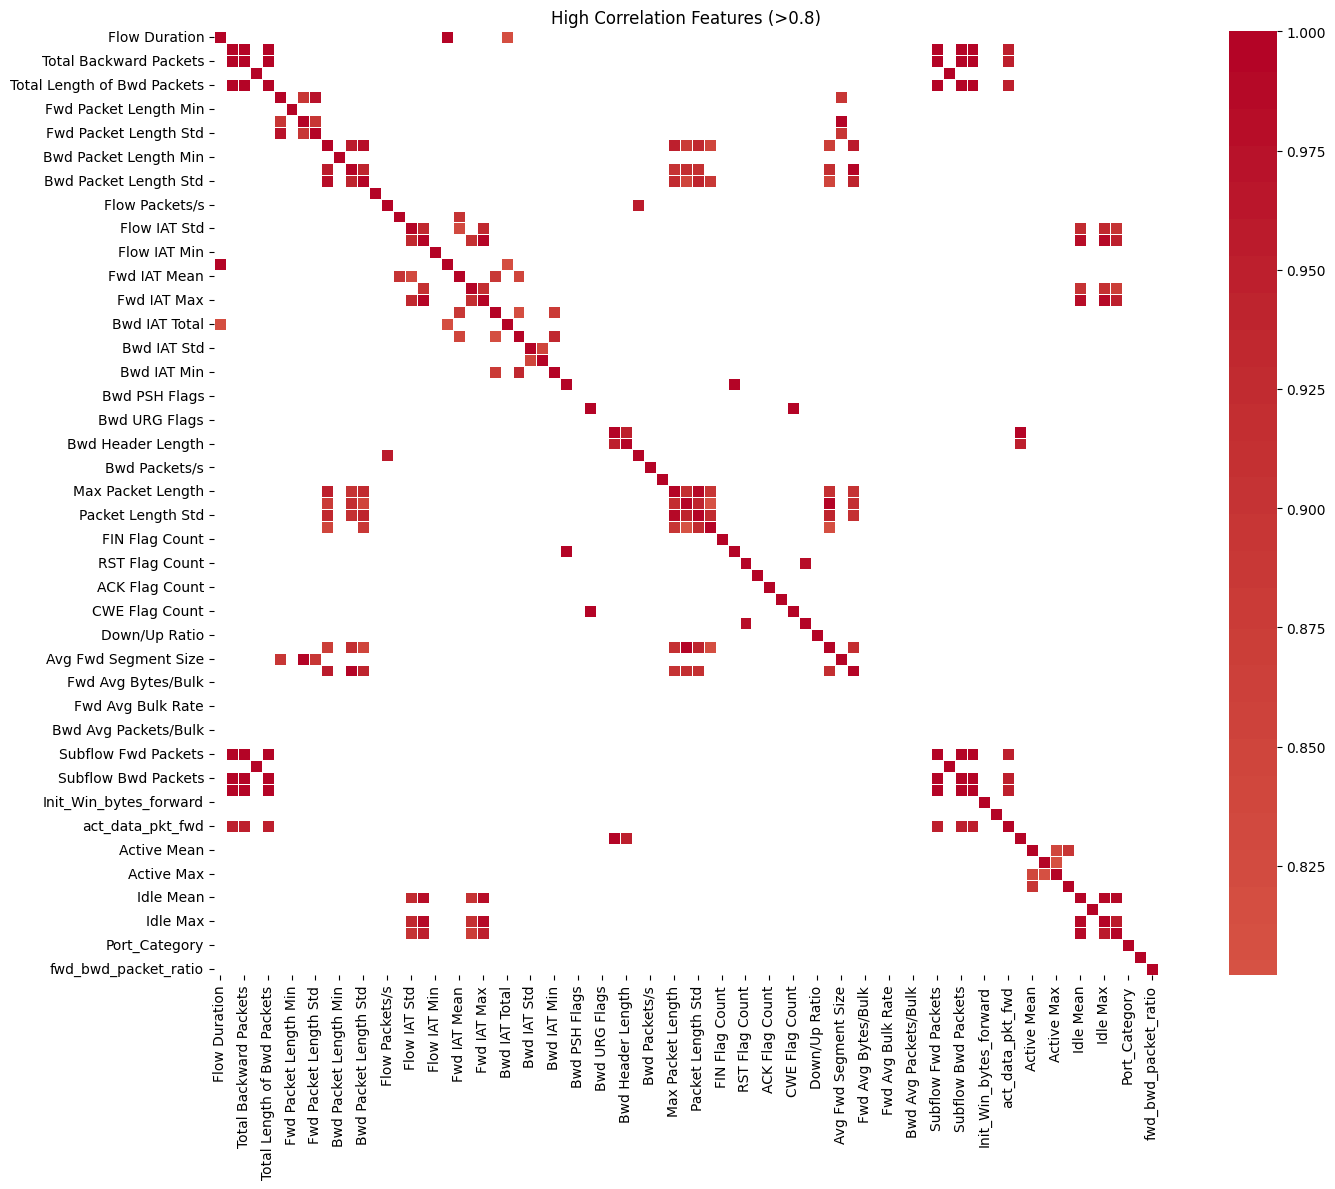

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
counts = df_all['Label'].value_counts()
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in counts.index]
counts.plot(kind='bar', color=colors)
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

import seaborn as sns

plt.figure(figsize=(12, 5))
sns.boxplot(data=sample, x='Label', y='Flow Duration', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Flow Duration by Attack Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=sample, x='Label', y='Flow Packets/s', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Flow Packets/s by Attack Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 12))
numeric_cols = sample.drop(columns=['Label']).columns
corr = sample[numeric_cols].corr()
mask = corr.abs() < 0.8  # only show strong correlations
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('High Correlation Features (>0.8)')
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df_all.drop(columns=['Label']).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} correlated features:")
print(to_drop)

df_all.drop(columns=to_drop, inplace=True)
print(f"\nRemaining shape: {df_all.shape}")

Dropping 22 correlated features:
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']

Remaining shape: (2217688, 58)


In [ ]:
from sklearn.feature_selection import VarianceThreshold

X_temp = df_all.drop(columns=['Label'])
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_temp)

low_var = X_temp.columns[~selector.get_support()].tolist()
print(f"Dropping {len(low_var)} low variance features:")
print(low_var)

df_all.drop(columns=low_var, inplace=True)
print(f"\nRemaining shape: {df_all.shape}")

Dropping 10 low variance features:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Remaining shape: (2217688, 48)


In [ ]:
features = [col for col in df_all.columns if col != 'Label']
print(f"Number of features: {len(features)}")
print(features)

Number of features: 47
['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Port_Category', 'payload_ratio_fwd', 'fwd_bwd_packet_ratio']


In [ ]:
df_all.to_parquet("/content/drive/MyDrive/cicids2017_clean.parquet", index=False)
df_all.to_parquet("/homecicids2017_clean.parquet", index=False)
print("Saved!")

Saved!


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_all['Label'] = le.fit_transform(df_all['Label'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Label mapping:
  0 → BENIGN
  1 → Bot
  2 → DDoS
  3 → DoS GoldenEye
  4 → DoS Hulk
  5 → DoS Slowhttptest
  6 → DoS slowloris
  7 → FTP-Patator
  8 → PortScan
  9 → SSH-Patator
  10 → Web Attack - Brute Force
  11 → Web Attack - XSS


In [ ]:
from sklearn.model_selection import train_test_split

X = df_all[features]
y = df_all['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1774150, 47)
Test size:  (443538, 47)


In [ ]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
X_train_scaled = rs.fit_transform(X_train)
X_test_scaled = rs.transform(X_test)

In [ ]:
import numpy as np

np.save("/content/drive/MyDrive/X_train.npy", X_train_scaled)
np.save("/content/drive/MyDrive/X_test.npy", X_test_scaled)
np.save("/content/drive/MyDrive/y_train.npy", y_train.values)
np.save("/content/drive/MyDrive/y_test.npy", y_test.values)

print("All splits saved!")

All splits saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib

X_train_scaled = np.load("/content/drive/MyDrive/X_train.npy")
X_test_scaled = np.load("/content/drive/MyDrive/X_test.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test:  {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (1774150, 47)
X_test:  (443538, 47)
y_train: (1774150,)
y_test:  (443538,)


In [ ]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

model.fit(X_train_scaled, y_train)
print("Training done!")

Training done!


In [ ]:
from sklearn.metrics import classification_report

labels = [
    'BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
    'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator',
    'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - XSS'
]

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=labels))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    376134
                     Bot       0.68      0.83      0.75       295
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.99      1.00      1.00      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       0.94      0.99      0.97      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
                PortScan       0.92      0.89      0.91       503
             SSH-Patator       1.00      1.00      1.00       644
Web Attack - Brute Force       0.75      0.68      0.71       294
        Web Attack - XSS       0.38      0.45      0.41       130

                accuracy                           1.00    443538
               macro avg       0.89      0.90      0.89    443538
        

In [ ]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/lgbm_nids.pkl")
print("Model saved!")

Model saved!


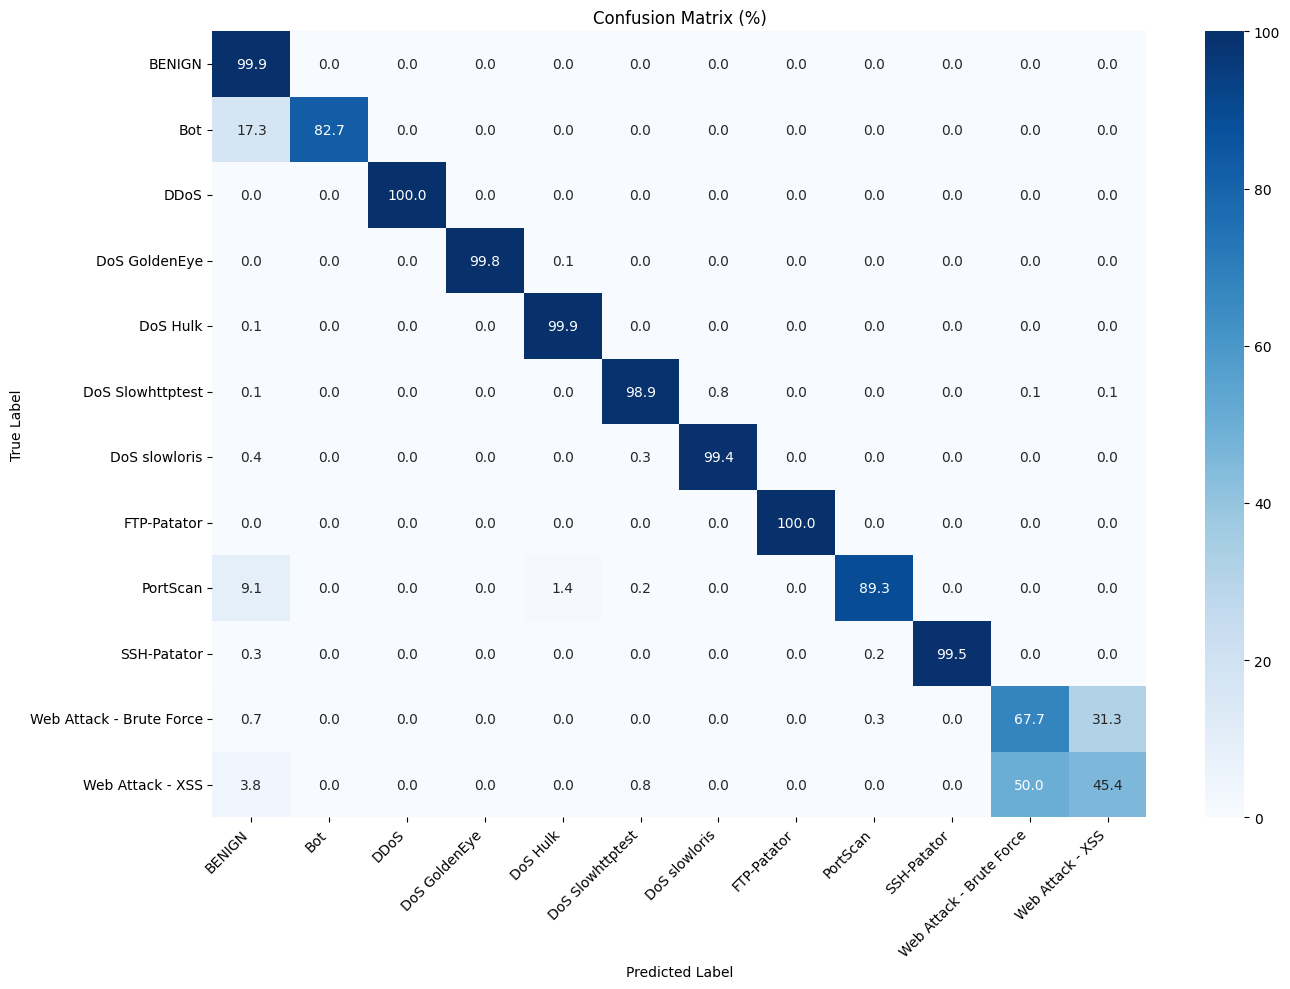

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(14, 10))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib
import lightgbm as lgb

X_train_scaled = np.load("/content/drive/MyDrive/X_train.npy")
X_test_scaled = np.load("/content/drive/MyDrive/X_test.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

model = joblib.load("/content/drive/MyDrive/lgbm_nids.pkl")
print("Everything loaded!")
print(f"X_test shape: {X_test_scaled.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything loaded!
X_test shape: (443538, 47)


In [2]:
import shap

features = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s',
 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min',
 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length',
 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count',
 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
 'Active Min', 'Idle Std', 'Port_Category', 'payload_ratio_fwd',
 'fwd_bwd_packet_ratio']

sample_idx = np.random.choice(len(X_test_scaled), 200, replace=False)
X_sample = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print(f"Shape: {np.array(shap_values).shape}")

Shape: (200, 47, 12)


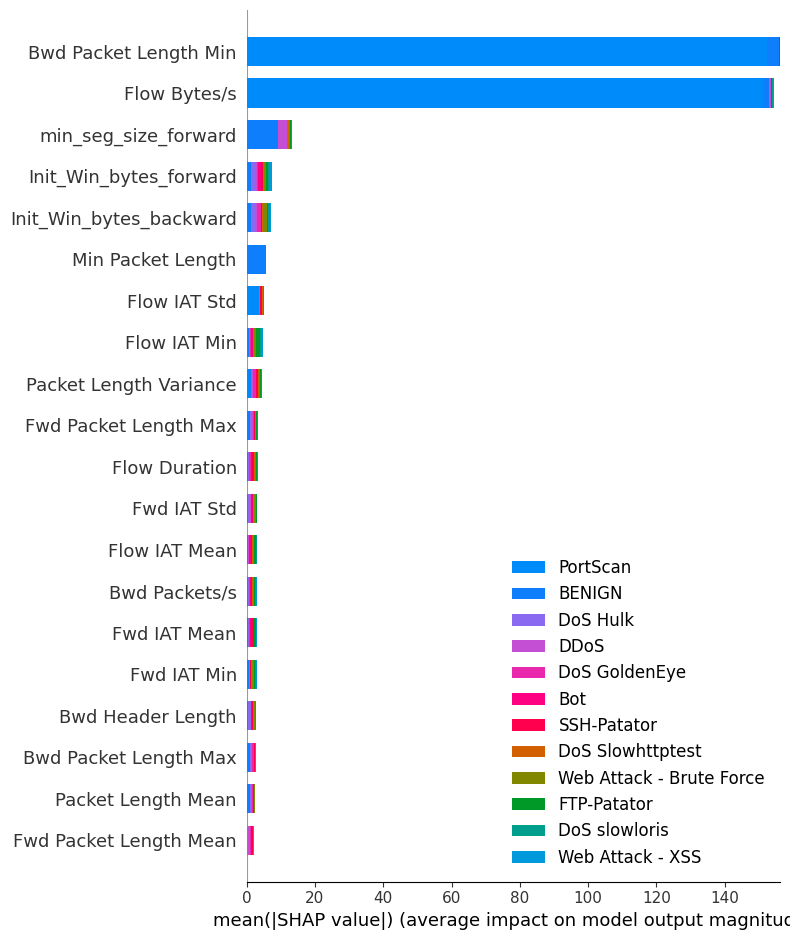

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=features,
    class_names=['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
                 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator',
                 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force',
                 'Web Attack - XSS'],
    plot_type="bar",
    max_display=20
)
plt.tight_layout()
plt.show()

Explaining DDoS sample at index: 8


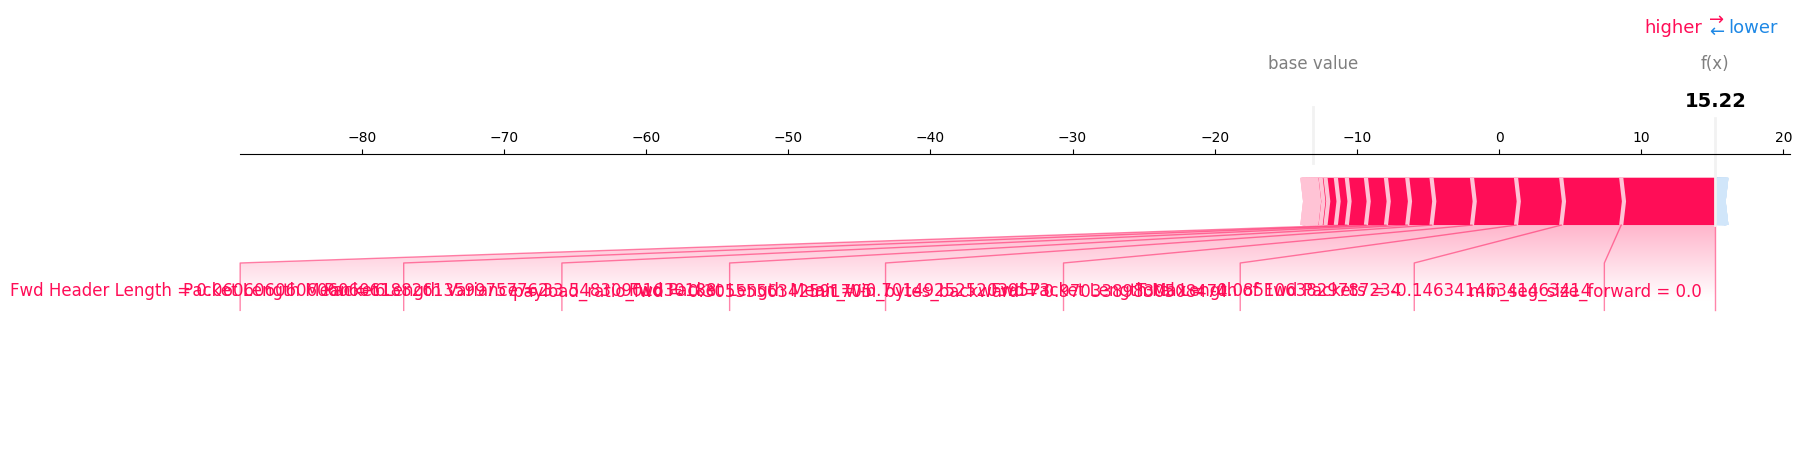

<Figure size 640x480 with 0 Axes>

In [6]:
import pandas as pd

# Convert sample to dataframe for SHAP
X_sample_df = pd.DataFrame(X_sample, columns=features)

# Find a DDoS sample (class 2)
y_test_sample = y_test[sample_idx]
ddos_idx = np.where(y_test_sample == 2)[0][0]

print(f"Explaining DDoS sample at index: {ddos_idx}")

shap.force_plot(
    explainer.expected_value[2],
    shap_values[ddos_idx, :, 2],
    X_sample_df.iloc[ddos_idx],
    feature_names=features,
    matplotlib=True,
    figsize=(20, 4)
)
plt.tight_layout()
plt.show()

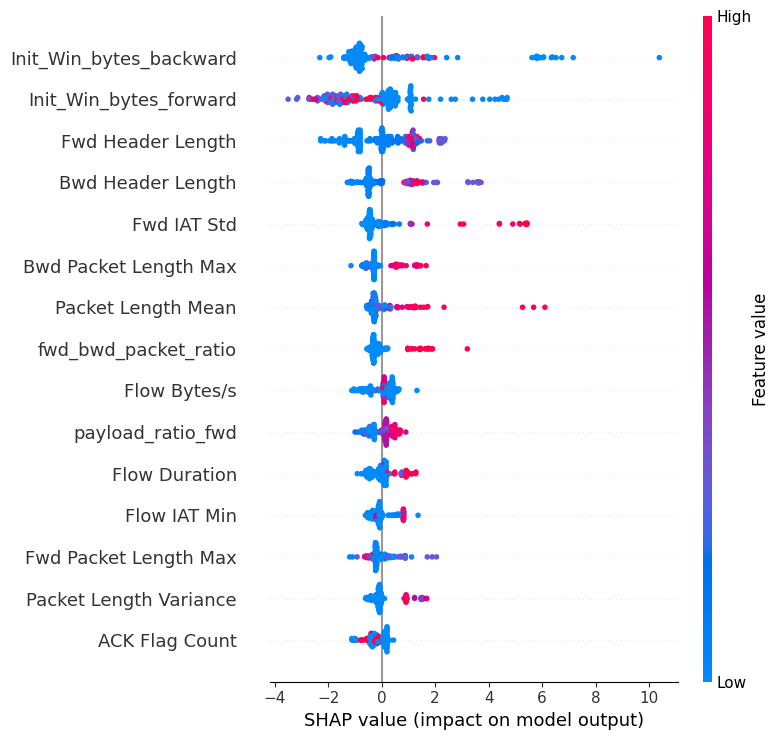

In [7]:
shap.summary_plot(
    shap_values[:, :, 4],
    X_sample_df,
    feature_names=features,
    max_display=15,
    show=True
)

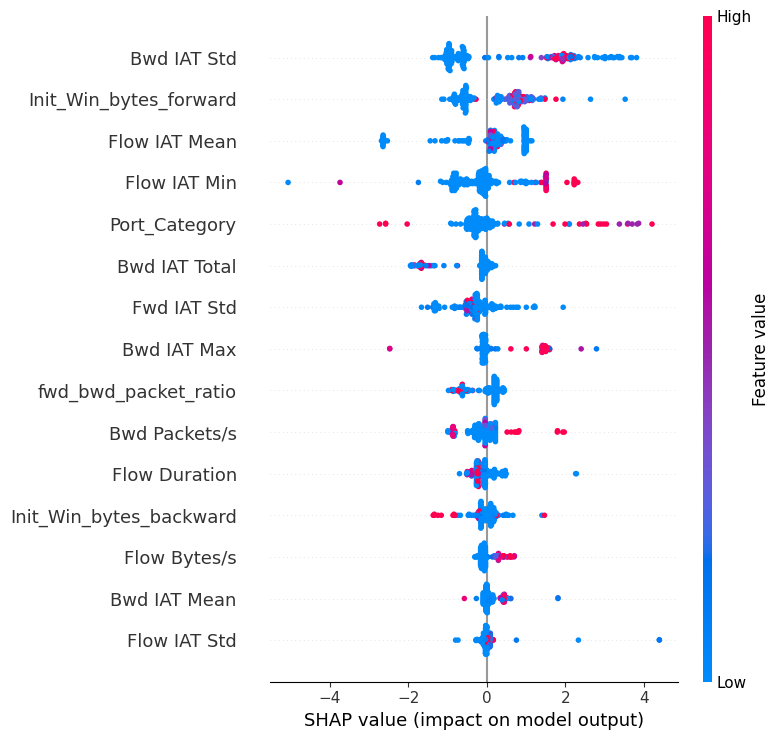

In [8]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample_df,
    feature_names=features,
    max_display=15,
    show=True
)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib
import pandas as pd

# Reload data and model
X_train_scaled = np.load("/content/drive/MyDrive/X_train.npy")
X_test_scaled = np.load("/content/drive/MyDrive/X_test.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")

model = joblib.load("/content/drive/MyDrive/lgbm_nids.pkl")

# Recompute predictions
y_pred = model.predict(X_test_scaled)

features = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s',
 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min',
 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length',
 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count',
 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
 'Active Min', 'Idle Std', 'Port_Category', 'payload_ratio_fwd',
 'fwd_bwd_packet_ratio']

labels_list = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
               'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator',
               'PortScan', 'SSH-Patator', 'Web Attack - Brute Force',
               'Web Attack - XSS']

print("Everything reloaded!")
print(f"Predictions shape: {y_pred.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Everything reloaded!
Predictions shape: (443538,)


In [11]:
from sklearn.metrics import recall_score, precision_score, f1_score
import pandas as pd
import numpy as np

labels_list = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
               'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator',
               'PortScan', 'SSH-Patator', 'Web Attack - Brute Force',
               'Web Attack - XSS']

recall_per_class = recall_score(y_test, y_pred, average=None)
precision_per_class = precision_score(y_test, y_pred, average=None)

results = pd.DataFrame({
    'Class': labels_list,
    'Recall': recall_per_class,
    'Precision': precision_per_class,
    'Miss Rate': 1 - recall_per_class,
    'Risk Level': ['LOW' if r > 0.95 else 'MEDIUM' if r > 0.80 else 'HIGH'
                   for r in recall_per_class]
})

results = results[results['Class'] != 'BENIGN']  # exclude benign
results = results.sort_values('Recall')
print(results.to_string(index=False))

                   Class   Recall  Precision  Miss Rate Risk Level
        Web Attack - XSS 0.453846   0.380645   0.546154       HIGH
Web Attack - Brute Force 0.676871   0.748120   0.323129       HIGH
                     Bot 0.827119   0.681564   0.172881     MEDIUM
                PortScan 0.892644   0.920082   0.107356     MEDIUM
        DoS Slowhttptest 0.989484   0.943482   0.010516        LOW
           DoS slowloris 0.993500   0.991659   0.006500        LOW
             SSH-Patator 0.995342   1.000000   0.004658        LOW
           DoS GoldenEye 0.998055   0.994189   0.001945        LOW
                DoS Hulk 0.998583   0.998294   0.001417        LOW
                    DDoS 0.999727   0.999570   0.000273        LOW
             FTP-Patator 1.000000   1.000000   0.000000        LOW


In [12]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Security Evaluation Summary ===")
print(f"Macro F1:    {macro_f1:.4f}  ← treat all classes equally")
print(f"Weighted F1: {weighted_f1:.4f}  ← dominated by BENIGN, ignore")
print()
print("=== Classes Needing Attention ===")
high_risk = results[results['Risk Level'] == 'HIGH']
print(high_risk[['Class', 'Recall', 'Miss Rate']].to_string(index=False))

=== Security Evaluation Summary ===
Macro F1:    0.8940  ← treat all classes equally
Weighted F1: 0.9986  ← dominated by BENIGN, ignore

=== Classes Needing Attention ===
                   Class   Recall  Miss Rate
        Web Attack - XSS 0.453846   0.546154
Web Attack - Brute Force 0.676871   0.323129


In [14]:
import lightgbm as lgb
import numpy as np
import pandas as pd

label_mapping = {
    0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye',
    4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris',
    7: 'FTP-Patator', 8: 'PortScan', 9: 'SSH-Patator',
    10: 'Web Attack - Brute Force', 11: 'Web Attack - XSS'
}

risk_mapping = {
    'BENIGN': 'NONE',
    'Bot': 'HIGH',
    'DDoS': 'CRITICAL',
    'DoS GoldenEye': 'CRITICAL',
    'DoS Hulk': 'CRITICAL',
    'DoS Slowhttptest': 'HIGH',
    'DoS slowloris': 'HIGH',
    'FTP-Patator': 'MEDIUM',
    'PortScan': 'MEDIUM',
    'SSH-Patator': 'MEDIUM',
    'Web Attack - Brute Force': 'HIGH',
    'Web Attack - XSS': 'HIGH'
}

def predict_traffic(flow_features, model, scaler, features):
    """
    Takes raw flow features, returns prediction with confidence and risk level.

    Args:
        flow_features: dict or dataframe row of network flow features
        model: trained LightGBM model
        scaler: fitted RobustScaler
        features: list of feature names

    Returns:
        dict with prediction, confidence, risk level, top contributing features
    """
    # Convert to dataframe
    if isinstance(flow_features, dict):
        X = pd.DataFrame([flow_features])
    else:
        X = pd.DataFrame([flow_features], columns=features)

    # Scale
    X_scaled = scaler.transform(X[features])

    # Predict
    pred_class = model.predict(X_scaled)[0]
    pred_proba = model.predict_proba(X_scaled)[0]

    label = label_mapping[pred_class]
    confidence = pred_proba[pred_class] * 100
    risk = risk_mapping[label]

    # Top 3 most likely classes
    top3_idx = np.argsort(pred_proba)[::-1][:3]
    top3 = [(label_mapping[i], f"{pred_proba[i]*100:.1f}%") for i in top3_idx]

    return {
        'prediction': label,
        'confidence': f"{confidence:.1f}%",
        'risk_level': risk,
        'top_3_possibilities': top3,
        'action': 'BLOCK' if risk in ['CRITICAL', 'HIGH'] else
                  'MONITOR' if risk == 'MEDIUM' else 'ALLOW'
    }

print("Pipeline ready!")

Pipeline ready!


In [16]:
from sklearn.preprocessing import RobustScaler

# Refit scaler on training data
scaler = RobustScaler()
scaler.fit(X_train_scaled)

# Save it
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
print("Scaler saved!")

Scaler saved!


In [19]:
test_cases = {
    'DDoS sample': np.where(y_test == 2)[0][0],
    'Bot sample': np.where(y_test == 1)[0][0],
    'Benign sample': np.where(y_test == 0)[0][0]
}

for name, idx in test_cases.items():
    flow = dict(zip(features, X_test_scaled[idx]))
    result = predict_traffic(flow, model, scaler, features)
    print(f"\n{'='*40}")
    print(f"Test case: {name}")
    print(f"  Prediction:  {result['prediction']}")
    print(f"  Confidence:  {result['confidence']}")
    print(f"  Risk Level:  {result['risk_level']}")
    print(f"  Action:      {result['action']}")
    print(f"  Top 3:       {result['top_3_possibilities']}")


Test case: DDoS sample
  Prediction:  DDoS
  Confidence:  100.0%
  Risk Level:  CRITICAL
  Action:      BLOCK
  Top 3:       [('DDoS', '100.0%'), ('PortScan', '0.0%'), ('BENIGN', '0.0%')]

Test case: Bot sample
  Prediction:  Bot
  Confidence:  100.0%
  Risk Level:  HIGH
  Action:      BLOCK
  Top 3:       [('Bot', '100.0%'), ('BENIGN', '0.0%'), ('SSH-Patator', '0.0%')]

Test case: Benign sample
  Prediction:  BENIGN
  Confidence:  100.0%
  Risk Level:  NONE
  Action:      ALLOW
  Top 3:       [('BENIGN', '100.0%'), ('Web Attack - Brute Force', '0.0%'), ('DoS slowloris', '0.0%')]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [20]:
# Refit scaler properly with dataframe instead of numpy array
import pandas as pd

X_train_df = pd.DataFrame(X_train_scaled, columns=features)
scaler = RobustScaler()
scaler.fit(X_train_df)
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
print("Scaler refitted cleanly — no more warnings!")

Scaler refitted cleanly — no more warnings!
